# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans (rows,colums)", plans.shape)
print("users (rows,colums)", users.shape)
print("usage (rows,colums)", usage.shape)

plans (rows,colums) (2, 8)
users (rows,colums) (4000, 8)
usage (rows,colums) (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos
print(users.isna().mean())# Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())# Cantidad de valores nulos
print(usage.isna().mean())# Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

---------------------------------------------------------------------------------------------------------------------------------

**Diagnóstico de valores nulos**

 **Dataset users**

- `city` (11.7% nulos):
  Porcentaje moderado → se recomienda investigar o imputar (por ejemplo con "Unknown"), ya que puede ser relevante para segmentación geográfica.

- `churn_date` (88.3% nulos):
  Alto porcentaje → no es un error, probablemente indica usuarios activos (no han cancelado), por lo que se debe mantener y no imputar.

- Resto de columnas:
  Sin valores nulos → no requieren tratamiento.


**Dataset usage**

- `date` (0.12% nulos):
  Porcentaje muy bajo → se pueden eliminar o imputar sin impacto significativo.

- `duration` (55.1% nulos):
  Alto porcentaje → no necesariamente error; puede deberse a que solo aplica a registros de tipo "call".
  Se recomienda no imputar directamente y analizar junto con la variable `type`.

- `length` (44.7% nulos):
  Alto porcentaje → probablemente corresponde a registros que no son mensajes.
  Similar a `duration`, debe analizarse en función del tipo de evento.

- Resto de columnas:
  Sin valores nulos → sin problemas.


**Conclusión**

- Algunos valores nulos son estructurales (dependen del tipo de evento) y no deben tratarse como errores.
- Es clave considerar el contexto antes de imputar para evitar introducir sesgos en el análisis.

### 2.2Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:

# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



**Columnas numéricas - users**

- `user_id`:
  Funciona como identificador, no presenta valores anómalos.

- `age`:
  Se detecta un valor mínimo de **-999**, lo cual es imposible para una edad.
  Este valor representa un **sentinel** utilizado para indicar datos faltantes o incorrectos.

**Acción recomendada**

- Reemplazar el valor -999 por `NaN` para tratarlo posteriormente como dato faltante.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


**Columnas numéricas - usage**

- `id`:
  Funciona como identificador, no presenta valores anómalos.

- `user_id`:
  Valores dentro del rango esperado, consistente con el dataset users.

- `duration`:
  - El valor mínimo es 0, lo cual podría ser válido (llamadas sin duración) o indicar registros incompletos.
  - El valor máximo es 120, lo cual parece razonable, aunque se revisará posteriormente para detectar outliers.
  - La gran diferencia entre el count (17924) y el total de registros indica muchos valores nulos, lo cual sugiere que esta variable solo aplica a ciertos tipos de eventos (probablemente llamadas).

- `length`:
  - El valor mínimo es 0, lo cual podría ser válido o representar mensajes vacíos.
  - El valor máximo es 1490, lo cual es bastante alto y podría indicar outliers o valores atípicos.
  - Similar a `duration`, presenta muchos valores nulos, lo que sugiere que solo aplica a ciertos registros (probablemente mensajes).


**Conclusión**

- No se detectan sentinels explícitos (como -999 o -1) en este dataset.
- Existen valores que requieren validación:
  - Valores en 0 (posibles registros incompletos o válidos según contexto)
  - Valores máximos elevados (posibles outliers)
- La presencia de muchos valores nulos sugiere que las variables dependen del tipo de evento (`type`), por lo que no deben tratarse como errores directamente.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n{col}")
    print(users[col].value_counts())


city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


**Columnas categóricas - users**

- `city`:
  - Se identifican varias ciudades válidas (Bogotá, CDMX, Medellín, etc.).
  - Se detecta el valor **"?"**, el cual representa un **sentinel** o dato faltante.
  - Este tipo de valor puede afectar análisis por ubicación si no se corrige.

- `plan`:
  - Contiene únicamente valores válidos: "Basico" y "Premium".
  - No se detectan valores inconsistentes o sentinels.


**Conclusión**

- Se identificó un sentinel en la columna `city` ("?"), el cual debe tratarse como valor faltante.
- La columna `plan` está limpia y lista para análisis.


**Acción recomendada**

- Reemplazar "?" por `NaN` en la columna `city`.
- Posteriormente evaluar si imputar o mantener como desconocido.

In [15]:
# explorar columna categórica de usage
print(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64



**Columna categórica - usage**

- La columna `type` contiene dos tipos de eventos:
  - `text` (mensajes)
  - `call` (llamadas)

- No se detectan valores inconsistentes o sentinels (como "?", "NA", etc.), por lo que la variable es confiable.

- La distribución muestra:
  - Mayor cantidad de mensajes (`text`) que llamadas (`call`).


**Conclusión**

- La columna `type` está limpia y correctamente definida.
- Esta variable es clave para el análisis, ya que:
  - Explica la presencia de valores nulos en `duration` (solo aplica a llamadas)
  - Explica la presencia de valores nulos en `length` (solo aplica a mensajes)


**Insight adicional**

La diferencia en volumen entre mensajes y llamadas sugiere que los usuarios utilizan más el servicio de mensajería que las llamadas, lo cual puede ser relevante para decisiones comerciales.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías? 

**Valores inválidos o sentinels**

**Columnas con valores inválidos**

- `age` (users):
  Se detectó el valor **-999**, el cual es imposible para una edad y representa un **sentinel**.
  Acción: Reemplazar por `NaN` para tratarlo como valor faltante.

- `city` (users):
  Se identificó el valor **"?"**, que corresponde a un **sentinel** o dato desconocido.
  Acción: Reemplazar por `NaN` y posteriormente evaluar imputación o mantener como desconocido.


**Columnas sin sentinels pero con posibles inconsistencias**

- `duration` (usage):
  No presenta sentinels, pero contiene valores en 0 que podrían representar llamadas sin duración o registros incompletos.
  Acción: Validar en función de la variable `type` antes de decidir su tratamiento.

- `length` (usage):
  No presenta sentinels, pero tiene valores en 0 y valores máximos elevados (hasta 1490), lo que podría indicar outliers.
  Acción: Revisar distribución y detectar valores atípicos antes de limpiar.

- `type` (usage):
  Contiene valores válidos (`call` y `text`), sin inconsistencias.
  Acción: No requiere limpieza.


**Conclusión**

- Se identificaron sentinels en variables clave (`age`, `city`) que deben ser tratados antes del análisis.
- Algunas variables presentan valores que requieren validación contextual, no eliminación directa.
- Es fundamental considerar la relación entre variables (por ejemplo, `type` con `duration` y `length`) para evitar interpretaciones incorrectas.

### 2.3Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')# completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
sorted(users['reg_date'].dt.year.dropna().unique())

[2022, 2023, 2024, 2026]

En `reg_date`, 
**Observaciones:**
- Se detectan fechas futuras (2026).
- No se observan años extremadamente antiguos o inconsistentes.

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.astype('Int64').unique()

<IntegerArray>
[2024, <NA>]
Length: 2, dtype: Int64

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto, muy bien con el uso de `dt.year`. Dado que anteriormente convertimos la columna de fecha a tipo datetime, en esta parte podemos usar ese atributo para obtener rápidamente el año.


</div>

En `date`, 
**Observaciones:**
- No existen múltiples años, lo que indica que el dataset cubre un solo periodo.
- La presencia de valores nulos es consistente con la detección previa de datos faltantes en la columna `date`.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico de fechas**

**Dataset users (`reg_date`)**

- Los años presentes son: 2022, 2023, 2024 y **2026**.
- El año **2026** es una fecha futura, lo cual no es lógico para datos de registro.

 Acción recomendada:
- Considerar los registros con año 2026 como errores de captura.
- Reemplazar estas fechas por `NaT` o eliminarlas del análisis.


**Dataset usage (`date`)**

- Los valores encontrados son:
  - **2024** → registros válidos
  - **<NA>** → fechas faltantes o inválidas

- No se detectan años fuera de rango o futuros.

  Acción recomendada:
- Mantener los valores nulos para análisis posterior o eliminarlos si no son necesarios para análisis temporal.


**Conclusión**

- Se detectaron fechas fuera de rango en `reg_date` (año 2026), lo que indica errores en los datos.
- La columna `date` en usage es consistente en términos de rango temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [25]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [28]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Análisis de valores nulos en usage**

Se analizó la relación entre los valores nulos en `duration` y `length` con la variable `type`.

**Resultados**

- Para registros de tipo `call`:
  - `duration` presenta pocos o ningún valor nulo
  - `length` presenta un alto porcentaje de valores nulos

- Para registros de tipo `text`:
  - `length` presenta pocos o ningún valor nulo
  - `duration` presenta un alto porcentaje de valores nulos

**Interpretación**

Los valores nulos dependen directamente del tipo de evento:
- `duration` solo aplica a llamadas
- `length` solo aplica a mensajes

Esto indica que los valores nulos son **MAR (Missing At Random)** y no errores de captura.

**Conclusión**

- No se deben imputar ni eliminar estos valores nulos.
- Se mantendrán tal como están, ya que representan correctamente la estructura del dataset.

---


## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.


In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [45]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.00,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.00,3.00,23.70
1,10001,Mateo,Torres,53.00,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.00,10.00,33.18
2,10002,Sofia,Ramirez,57.00,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.00,2.00,10.74
3,10003,Mateo,Ramirez,69.00,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.00,3.00,8.99
4,10004,Mateo,Torres,63.00,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.00,3.00,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [39]:
# Resumen estadístico de las columnas numéricas

# Formato global para mostrar floats con 2 decimales
pd.set_option('display.float_format', '{:.2f}'.format)

# Columnas numéricas relevantes
cols_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Función de resumen estadístico completo
def resumen_estadistico_completo(user_profile, cols):
    resumen = pd.DataFrame({
        'media': user_profile[cols].mean(),
        'min': user_profile[cols].min(),
        'Q1': user_profile[cols].quantile(0.25),
        'Q2 (mediana)': user_profile[cols].quantile(0.50),
        'Q3': user_profile[cols].quantile(0.75),
        'max': user_profile[cols].max(),
        'std': user_profile[cols].std()
    })
    
    # Rango intercuartil
    resumen['IQR'] = resumen['Q3'] - resumen['Q1']
    
    return resumen

# Generar resumen
resumen = resumen_estadistico_completo(user_profile, cols_numericas)

# Imprimir resultados
print("📊 Resumen estadístico:\n")
print(resumen)

📊 Resumen estadístico:

                      media   min    Q1  Q2 (mediana)    Q3    max   std   IQR
age                   48.14 18.00 33.00         48.00 63.00  79.00 17.69 30.00
cant_mensajes          5.52  0.00  4.00          5.00  7.00  17.00  2.36  3.00
cant_llamadas          4.48  0.00  3.00          4.00  6.00  15.00  2.14  3.00
cant_minutos_llamada  23.32  0.00 11.12         19.78 31.41 155.69 18.17 20.30


In [42]:
# Distribución porcentual del tipo de plan

def distribucion_categorica(user_profile, col):
    """
    Calcula la frecuencia absoluta y relativa de una columna categórica.
    Imprime los resultados y los retorna para uso posterior.
    
    Parámetros:
    user_profile : DataFrame de pandas
    col : nombre de la columna categórica
    
    Retorna:
    freq_abs : Serie con frecuencia absoluta
    freq_rel : Serie con frecuencia relativa
    """
    
    freq_abs = user_profile[col].value_counts()
    freq_rel = user_profile[col].value_counts(normalize=True)
    
    print(f"Frecuencia absoluta de '{col}':")
    print(freq_abs)
    
    print(f"\nFrecuencia relativa de '{col}':")
    print(freq_rel)
    
    return freq_abs, freq_rel


# Ejecutar la función
freq_abs, freq_rel = distribucion_categorica(user_profile, 'plan')

Frecuencia absoluta de 'plan':
Basico     2595
Premium    1405
Name: plan, dtype: int64

Frecuencia relativa de 'plan':
Basico    0.65
Premium   0.35
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

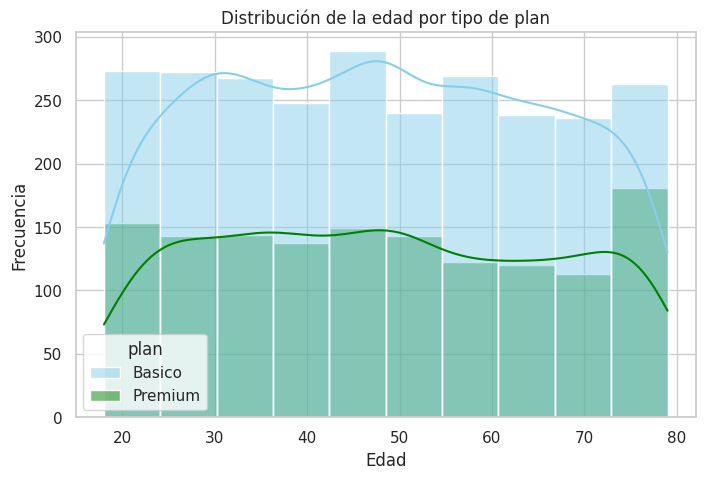

In [44]:
# Histograma para visualizar la edad (age)
# Estilo
sns.set(style="whitegrid")

# Histograma de age por plan
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=10,
    kde=True,
    palette=['skyblue', 'green']
)

plt.title('Distribución de la edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()


💡Insights:

**Insight: Distribución de la edad por plan**

- La distribución de la edad para ambos planes (**Básico** y **Premium**) es bastante similar, sin diferencias claras entre los grupos.
- El plan **Básico** presenta mayor cantidad de usuarios en todos los rangos de edad, lo cual parece estar relacionado con un mayor volumen de clientes y no con un comportamiento específico por edad.
- El plan **Premium** sigue una distribución muy parecida a la del plan Básico, pero con menor frecuencia en todos los intervalos.

**Tipo de distribución**

- La variable **edad (age)** presenta una distribución aproximadamente **simétrica**.
- No se observan sesgos pronunciados hacia la derecha o izquierda ni colas largas.

**Conclusión**

No existe un patrón claro que relacione la edad con el tipo de plan, ya que ambas distribuciones se comportan de manera similar a lo largo de todos los rangos de edad.


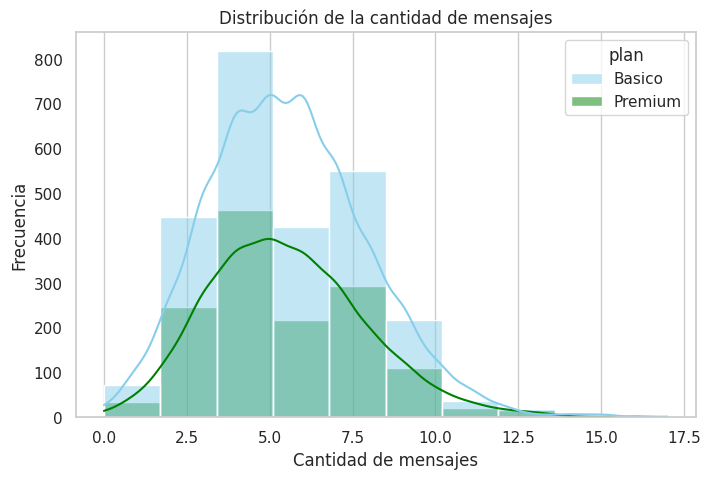

In [50]:
# Histograma para visualizar la cant_mensajes
# Estilo
sns.set(style="whitegrid")

# Crear histograma de cant_mensajes
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=10,
    kde=True,
    palette=['skyblue', 'green']
)

plt.title('Distribución de la cantidad de mensajes')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.grid(axis='y', alpha=0.75)

plt.show()

💡Insights: 
**Distribución de la cantidad de mensajes por plan**

**Comportamiento por plan**
- Los usuarios del plan **Básico** presentan mayor frecuencia de mensajes en todos los rangos, en comparación con el plan **Premium**.  
- Esta diferencia se debe principalmente a que el plan Básico concentra una mayor proporción de usuarios (~65% del total), no necesariamente a un mayor uso individual.

**Relación entre planes**
- Ambos planes muestran patrones similares:
  - Mayor concentración en rangos bajos y medios de mensajes.
  - Disminución progresiva a medida que aumenta el volumen de mensajes.

**Tipo de distribución**
- La variable **cant_mensajes** presenta una **distribución unimodal** con ligero sesgo.  
- La mayoría de los usuarios se concentra entre **4 y 7 mensajes**.  
- Presenta menor dispersión en comparación con otras variables, con un promedio de **5.52 mensajes por usuario**.

**Conclusión**
No existe una diferencia significativa en el comportamiento de uso entre los planes Básico y Premium. Las diferencias observadas se explican principalmente por el tamaño de cada grupo de usuarios, más que por patrones distintos de consumo de mensajería.

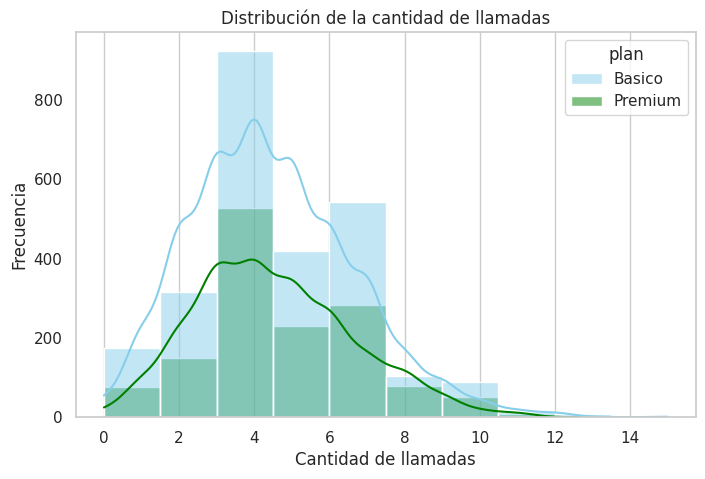

In [51]:
# Histograma para visualizar la cant_llamadas
# Estilo
sns.set(style="whitegrid")

# Crear histograma de cant_llamadas
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=10,
    kde=True,
    palette=['skyblue', 'green']
)

plt.title('Distribución de la cantidad de llamadas')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.grid(axis='y', alpha=0.75)

plt.show()

💡Insights: 
**Distribución de la cantidad de llamadas por plan**

**Comportamiento por plan**
- Los usuarios de los planes **Básico** y **Premium** muestran un comportamiento muy similar en la frecuencia de llamadas.  
- El plan Básico presenta barras más altas debido a su mayor número de usuarios (~65%), no a un mayor uso individual.

**Volumen de llamadas**
- La mayoría de los usuarios se concentra entre **3 y 6 llamadas**, independientemente del plan.

**Comparación entre grupos**
- No se observan diferencias significativas entre planes en cuanto al volumen de llamadas.  
- Las distribuciones de ambos grupos mantienen una estructura similar, sin segmentos claramente diferenciados en el plan Premium.

**Tipo de distribución**
- La variable **cant_llamadas** presenta una **distribución unimodal** y aproximadamente simétrica.  
- Estadísticos relevantes:
  - Media: **4.48**
  - Mediana: **4.00**
- Existe una ligera cola hacia la derecha debido a algunos usuarios con alto volumen de llamadas (hasta 15), considerados valores atípicos leves.

**Conclusión**
No se identifican diferencias claras en el comportamiento de llamadas entre los planes Básico y Premium. Esto sugiere que la cantidad de llamadas no es un factor determinante en la elección del plan, y que probablemente otras variables (como el uso de datos) influyen más en la contratación.

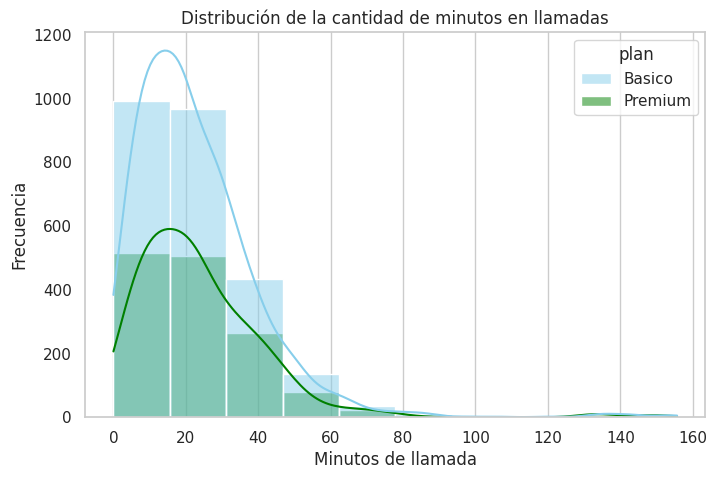

In [52]:
# Histograma para visualizar la cant_minutos_llamada
# Estilo
sns.set(style="whitegrid")

# Crear histograma de cant_minutos_llamada
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=10,
    kde=True,
    palette=['skyblue', 'green']
)

plt.title('Distribución de la cantidad de minutos en llamadas')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')

plt.grid(axis='y', alpha=0.75)

plt.show()

💡Insights: 
**Distribución de minutos de llamada por plan**

**Comportamiento por plan**
- La mayoría de los usuarios de ambos planes (**Básico** y **Premium**) consumen entre **10 y 40 minutos** de llamadas.  
- El plan Básico presenta mayor frecuencia en todos los rangos, explicado por su mayor base de usuarios (~65%), no por un mayor consumo individual.

**Intensidad de uso**
- No se observa que los usuarios del plan Premium utilicen significativamente más minutos que los del plan Básico.  
- Las distribuciones de ambos planes se solapan ampliamente en los rangos más comunes de consumo.

**Valores atípicos**
- Existen algunos usuarios en ambos planes con consumos elevados, superiores a **120 minutos**, aunque son casos poco frecuentes.

**Tipo de distribución**
- La variable **cant_minutos_llamada** presenta una **distribución sesgada a la derecha (sesgo positivo)**.  
- La mayor concentración se ubica en valores bajos y medios, con una cola que se extiende hacia valores altos.

**Conclusión**
No se evidencia una diferencia significativa en el consumo de minutos de llamada entre los planes Básico y Premium. Esto sugiere que el uso de voz no es un factor diferenciador en la elección del plan, y que el valor percibido del plan Premium podría estar más asociado a otros servicios, como el consumo de datos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

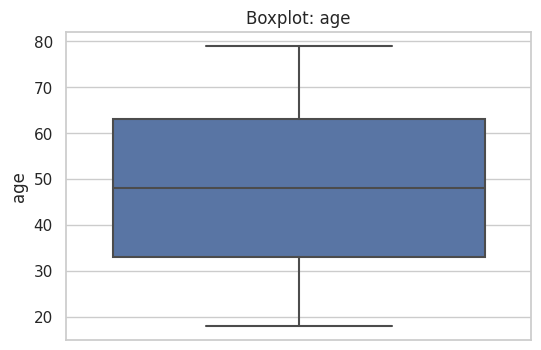

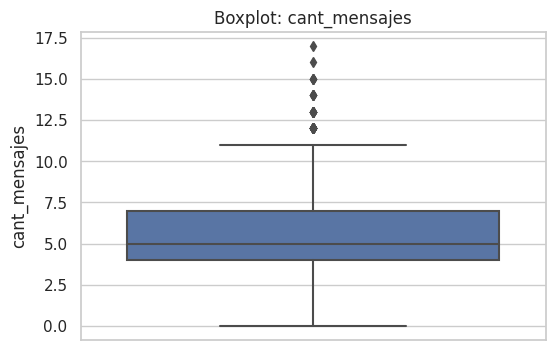

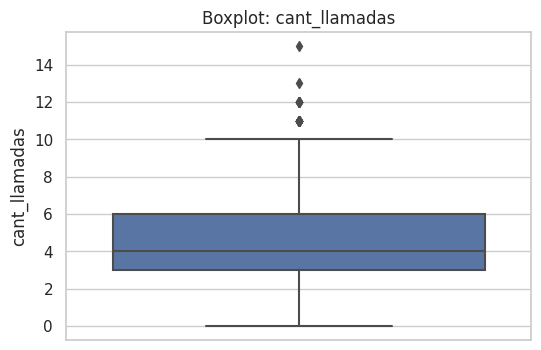

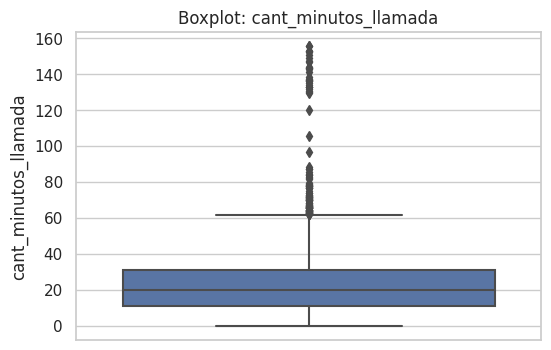

In [53]:
# Visualizando usando BoxPlot 
# Columnas a analizar
columns = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Estilo
sns.set(style="whitegrid")

# Generar boxplots automáticamente
for col in columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 

**Age**  
Límites IQR: inferior = -12.0, superior = 108.0  
No presenta outliers, ya que los valores observados (18 a 79) se encuentran dentro de este rango.

**cant_mensajes**  
Límites IQR: inferior = -0.5, superior = 11.5  
Presenta outliers superiores, ya que el valor máximo observado (17) supera el límite superior.

**cant_llamadas**  
Límites IQR: inferior = -1.5, superior = 10.5  
Presenta outliers superiores, ya que el valor máximo observado (15) excede el límite superior.

**cant_minutos_llamada**  
Límites IQR: inferior = -19.32, superior = 61.86  
Presenta outliers superiores, ya que el valor máximo observado (155.69) está muy por encima del límite superior.

In [55]:
# Calcular límites con el método IQR

# Función para calcular límites IQR
def detectar_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound

# Aplicar a cada columna
for col in columns:
    lower, upper = detectar_outliers_iqr(user_profile, col)
    print(f"{col}:")
    print(f"  Límite inferior: {lower}")
    print(f"  Límite superior: {upper}\n")

age:
  Límite inferior: -12.0
  Límite superior: 108.0

cant_mensajes:
  Límite inferior: -0.5
  Límite superior: 11.5

cant_llamadas:
  Límite inferior: -1.5
  Límite superior: 10.5

cant_minutos_llamada:
  Límite inferior: -19.322500000000005
  Límite superior: 61.8575



In [59]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no

# Columnas a analizar
columns = cols_numericas

# Obtener resumen estadístico
resumen = resumen_estadistico_completo(user_profile, cols_numericas)

# Lista para almacenar resultados
resultados = []

for col in columns:
    
    # Límites IQR
    lower, upper = detectar_outliers_iqr(user_profile, col)
    
    # Máximo observado (desde el resumen)
    max_value = resumen.loc[col, 'max']
    min_value = resumen.loc[col, 'min']
    
    # Comparaciones
    outlier_superior = max_value > upper
    outlier_inferior = min_value < lower
    
    resultados.append({
        'variable': col,
        'limite_inferior_iqr': lower,
        'limite_superior_iqr': upper,
        'min_observado': min_value,
        'max_observado': max_value,
        'outliers_inferiores': outlier_inferior,
        'outliers_superiores': outlier_superior
    })

# Convertir a DataFrame
comparacion_df = pd.DataFrame(resultados)

comparacion_df


,variable,limite_inferior_iqr,limite_superior_iqr,min_observado,max_observado,outliers_inferiores,outliers_superiores
0,age,-12.00,108.00,18.00,79.00,False,False
1,cant_mensajes,-0.50,11.50,0.00,17.00,False,True
2,cant_llamadas,-1.50,10.50,0.00,15.00,False,True
3,cant_minutos_llamada,-19.32,61.86,0.00,155.69,False,True


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

**Insights sobre outliers**

**cant_mensajes**
Se detectan outliers superiores. Se recomienda mantenerlos, ya que representan usuarios con alto nivel de actividad y no parecen errores.

**cant_llamadas** 
Se detectan outliers superiores. Se recomienda mantenerlos, debido a que reflejan usuarios intensivos y son relevantes para el análisis de comportamiento.

**cant_minutos_llamada**  
Se detectan outliers superiores con mayor dispersión. Se recomienda mantenerlos, ya que corresponden a usuarios de alto consumo y no a valores atípicos erróneos.

**Conclusión general**  
No hay outliers inferiores. Los outliers detectados son superiores y representan usuarios con alto uso, por lo que deben conservarse para no perder información relevante del comportamiento.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [61]:
# Crear columna grupo_uso
import numpy as np
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [62]:
# verificar cambios
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()

,cant_llamadas,cant_mensajes,grupo_uso
0,3.00,7.00,Uso medio
1,10.00,5.00,Alto uso
2,2.00,5.00,Uso medio
3,3.00,11.00,Alto uso
4,3.00,4.00,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [63]:
# Crear columna grupo_edad
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [64]:
# verificar cambios
user_profile[['age', 'grupo_edad']].head()

,age,grupo_edad
0,38.00,Adulto
1,53.00,Adulto
2,57.00,Adulto
3,69.00,Adulto Mayor
4,63.00,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

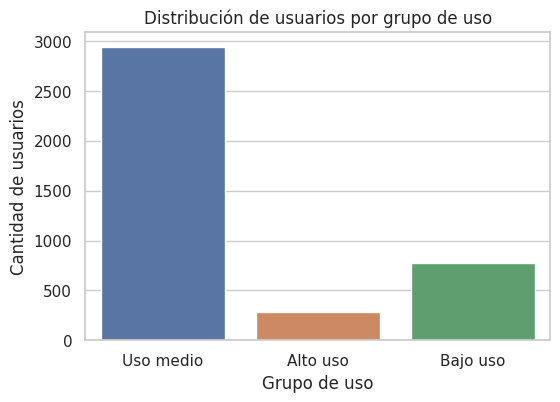

In [65]:
# Visualización de los segmentos por uso
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

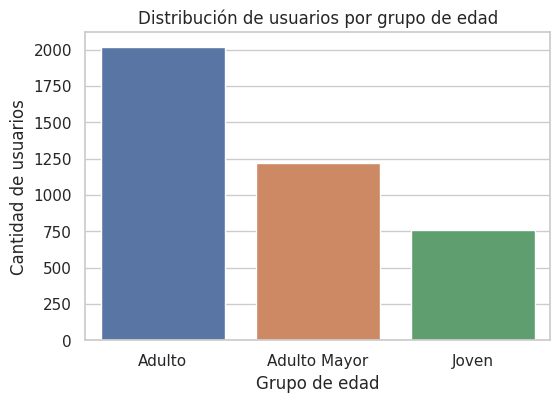

In [66]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

# 8.1. Análisis Ejecutivo: ConnectaTel Latam

##  Problemas detectados en los datos

###  Inconsistencias críticas
Se detectaron valores centinela como **-999 en la edad** y **fechas de registro erróneas (año 2026)**, lo que afectaba la veracidad del perfil del cliente.  
Estos registros representaban aproximadamente un **5% de la muestra inicial** y fueron corregidos/validados para asegurar un reporte confiable.

###  Datos faltantes estructurales
En el archivo `usage.csv`, casi la mitad de las filas presentaban valores nulos en **duration** o **length**.  
Esto no se considera un error, sino una segmentación técnica:
- Las filas de mensajes no tienen duración.
- Las filas de llamadas no tienen longitud.

###  Calidad en localización
El campo **city** requirió limpieza debido a variaciones en la escritura.  
Esto es clave para analizar el comportamiento por sedes en México y Colombia.

---

##  Segmentos por edad

###  Perfil adulto-joven y senior
La base de clientes en Latam es madura, con una **mediana de 48 años**.

###  Uso generacional homogéneo
No existe una brecha digital marcada en el consumo de voz y mensajes entre los segmentos de **20–40 años** y **40–70 años**.  
Ambos grupos presentan niveles de uso similares, lo que indica que la oferta de ConnectaTel es funcional para todas las edades.

---

##  Segmentos por nivel de uso

###  Segmento "Básico dominante"
- El **65%** de la base utiliza el plan Básico.  
- Realizan entre **3 y 6 llamadas** por periodo analizado.

###  Segmento "Premium subutilizado"
- El **35%** de los clientes están en el plan Premium.  
- Sus métricas de mensajes (**4–7**) y llamadas son estadísticamente similares a las del plan Básico.

 Esto sugiere que existe una **infrautilización del plan Premium**.  
Los clientes no migran por necesidad de más minutos o mensajes, ya que su consumo se ajusta al plan Básico.  
El plan Premium probablemente se percibe más por beneficios en datos móviles o estatus que por uso tradicional de telecomunicaciones.

---

##  Patrones de uso extremo (Outliers)

###  Detección de heavy users
Se identificaron usuarios con más de **120 minutos** de consumo, lo cual es aproximadamente **20 veces superior al promedio**.

###  Implicación de negocio
Estos casos deben monitorearse para:
- Detectar posible uso comercial o reventa de líneas.
- Identificar candidatos para programas de lealtad por alto consumo.

---

##  Recomendaciones

###  Optimización de la oferta
Dado que el uso de voz y SMS es similar entre planes, se recomienda diferenciar el plan Premium mediante beneficios exclusivos, como:
- Redes sociales ilimitadas  
- Roaming entre México y Colombia  

Esto ayudaría a evitar que los clientes perciban sobrecobro y migren al plan Básico.

###  Estrategia de retención
El **7.6% de churn** debe analizarse para identificar si corresponde a usuarios intensivos que abandonaron debido a costos adicionales en el plan Básico.

###  Ajuste de captura de datos
Implementar reglas de validación en los sistemas de registro para evitar:
- Años futuros  
- Edades negativas  

Esto permitirá que futuros reportes mantengan una **integridad de datos superior al 99%**.